# Kalman Filter at the gene scale
- gene phase/amp
- Introduce the Kalman filter
- Densities of wave number k, k/σk , k vs gene length.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
from functools import partial
import string

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import numpy as np
import pandas as pd
import pyBigWig as bw
import os
from scipy.optimize import curve_fit


import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc
sys.path.insert(0, '/home/jbreda/PROseq/scripts/FourierTransform')
from fourier_transform import fourier_transform

import threading
print(threading.active_count(), 'threads active at start')

from multiprocessing import Pool

import h5py

from KalmanFilter import KalmanFilter, KalmanFilter_k_hidden

fig_folder = '../results/fig/fig3'

def get_gtf(infile):

    # Read gtf file
    gtf = pd.read_csv(infile,sep='\t',header=None)
    gtf.columns = ['chr','source','type','start','end','score','strand','frame','attribute']
    gtf['gene_name'] = gtf.attribute.str.extract(r'gene_name "(.*?)";')
    N_gene = gtf.shape[0]

    # fix gene duplicates
    dup = gtf.gene_name.value_counts()
    my_genes = dup[dup>1].index
    for g in my_genes:
        idx = gtf[gtf.gene_name==g].index
        same_chr = (gtf.loc[idx,['chr','strand']].nunique().values == 1).all()
        overlap =  gtf.loc[idx,'end'].max() - gtf.loc[idx,'start'].min() < (gtf.loc[idx,'end'].values - gtf.loc[idx,'start'].values).sum()*2
        #gtf.loc[idx,['start']].values.max() < gtf.loc[idx,['end']].values.min()
        if same_chr and overlap:

            gtf.loc[idx[0],'start'] = gtf.loc[idx,'start'].min()
            gtf.loc[idx[0],'end'] = gtf.loc[idx,'end'].max()
            gtf.drop(idx[1:],inplace=True)
            
        else:
            print(g)
            gtf.loc[idx,'gene_name'] = [f'{g}_{i}' for i in range(len(idx))]
    gtf.set_index('gene_name',inplace=True,drop=True)

    return gtf

def get_data(coord, bw_folder, bin_size,fill_empty_bin=True):

    T = np.arange(0,48,4)
    strand_dict = {'+': 'forward', '-': 'reverse'}
    [chr,start,end,strand] = coord.split(':')
    start = int(start)
    end = int(end)

    # Load bigWigs to dataframe
    df = pd.DataFrame(columns=['start','end'])
    for t in T:
        sample = f'CT{t:02d}'
        fin = f"{bw_folder}/{sample}/NormCoverage_3p_{strand_dict[strand]}_bin{bin_size}bp.bw"
        with bw.open(fin,'r') as bw_file:
            df_t = pd.DataFrame(bw_file.intervals(chr,start,end),columns=['start','end',f"{t}"])
        df = pd.merge(df,df_t,on=['start','end'],how='outer')
    df.sort_values('start',inplace=True)
    df.reset_index(inplace=True,drop=True)

    # replace start and end with position in the middle of the bin, and set as index
    df['start'] = ( df.start.values + bin_size/2 ).astype(int) # bp
    df.rename(columns={'start':'pos'},inplace=True)
    df.drop('end',axis=1,inplace=True)
    df.set_index('pos',inplace=True)

    # fill empty bins with 0
    if fill_empty_bin:
        start_bin = start//bin_size*bin_size + int(bin_size/2)
        end_bin = int(np.ceil(end/bin_size)*bin_size) - int(bin_size/2)
        x = np.arange(start_bin, end_bin+1, bin_size)
        positions = df.index.values
        missing_pos = np.setdiff1d(x,positions)
        missing = pd.DataFrame(np.zeros((missing_pos.shape[0],df.shape[1])),index=missing_pos,columns=df.columns)
        df = pd.concat([df,missing],axis=0)
        df.sort_index(inplace=True)
        
    df.fillna(0,inplace=True)
    df = df.apply(lambda x: np.log2(x+1),axis=1)

    return df


7 threads active at start


## get data

In [2]:
bin_size = 1000 # bin size
genome = 'GRCm38'

T = np.arange(0,48,4) # time points [h]
P = 24 # period [h]
ω = 2*np.pi/P # angular frequency [rad/h]
m = len(T) # number of time points
dx = bin_size # distance between positions [bp]

# get gene phase and amplitude perbin for each gene
bw_folder = f'../results/{genome}/binned_norm_coverage'
file_gene_phase = f'../results/{genome}/phase_amp/gene_phase_amp.csv'
gene_phase_amp = pd.read_csv(file_gene_phase,index_col=-1,sep='\t')

infile_kalman_on_genes = f'../results/{genome}/kalman/Gene_Q_1e-5/Kalman_Smoothing_{bin_size}bp.hdf5'
with h5py.File(infile_kalman_on_genes, 'r') as hf:
    K = hf['K'][:]

    Genes = list(hf.keys())
    Genes.remove('K')
    Genes = np.array(Genes)
    LL = np.zeros((len(K),len(Genes)))
    adjR2 = np.zeros([len(Genes),2])
    strand = np.zeros(len(Genes),dtype=int)
    for g, gene in enumerate(Genes):
        LL[:,g] = hf[gene]['LL'][:]
        #X = hf[gene]['measurements'][:]
        #smoothed = hf[gene]['smoothed'][:]
        adjR2[g,0] = hf[gene].attrs['adjR2_fourier']
        adjR2[g,1] = hf[gene].attrs['adjR2_kf']
        strand[g] = (1 if hf[gene].attrs['strand'] == '+' else -1)

# make dataframe
df = gene_phase_amp.copy()
df = df.loc[Genes,:]
df['Length'] = df.end - df.start
df['K_max'] = K[np.argmax(LL,axis=0)]
df['speed_max'] = -(ω/3600)/( df['K_max'] )
df['lambda_max_kb'] = (2*np.pi/df.K_max)*1e-3
df['LL_ratio'] = (LL.max(axis=0,keepdims=True) - LL[K==0,:])[0,:]/np.log(2)
df['LL_max'] = LL.max(axis=0)
df['adjR2_f'] = adjR2[:,0]
df['adjR2_kf'] = adjR2[:,1]
n = 12
p = 3
df['adjR2'] = 1 - (1 - df.R2.values)*(n-1)/(n-p-1)
df['strand'] = strand

# flip LL for reverse genes
for g in df.index[df.strand==-1]:
    LL[:,df.index==g] = LL[::-1,df.index==g]

# Take log10 of some columns and rename
df.pval = np.log10(df.pval)
df.Length = np.log10(df.Length)
df.mean_count_per_bp = np.log10(df.mean_count_per_bp)
df.rename(columns={'Length':'log10 Length','mean_count_per_bp':'log10 mean_count_per_bp','pval':'log10 pval'},inplace=True)



## Transcription speed vs. length and $k$ probability density

2968
265


/home/jbreda/miniforge3/envs/pro-seq/lib/python3.12/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


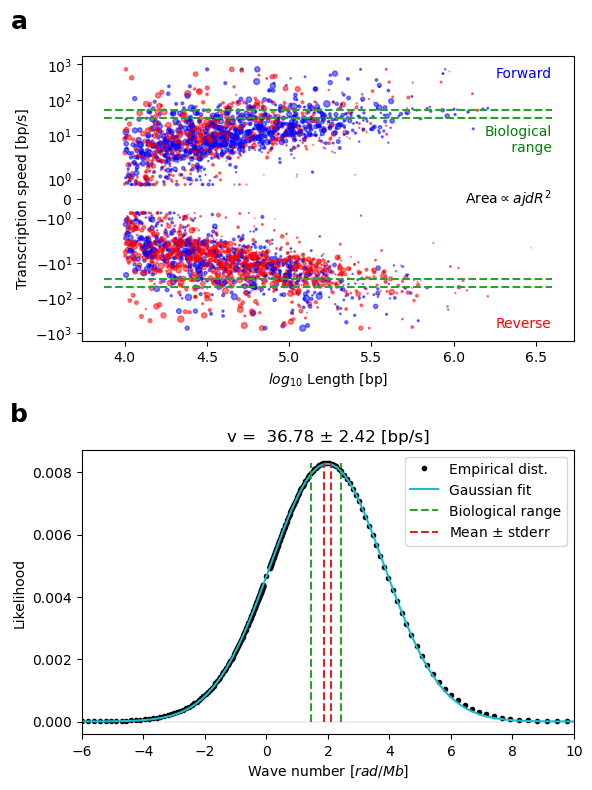

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))



# Thresholds
th = {}
th['log10 Length'] = np.log10(1e4)
th['log10 mean_count_per_bp'] = -2
th['log10 pval'] = -2
idx_top = (df['log10 Length'] >= th['log10 Length']) & (df['log10 mean_count_per_bp'] >= th['log10 mean_count_per_bp']) & (df['log10 pval'] <= th['log10 pval'])

print(idx_top.sum())
ax = axes[0]
ax.scatter(x=df.loc[idx_top,'log10 Length'],y=df.loc[idx_top,'speed_max'],s=100*(df.loc[idx_top,'adjR2_kf']),c=df.loc[idx_top,'strand'],cmap='bwr_r',marker='.',alpha=.5)
ax.set_yscale('symlog')
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.hlines(xmin=xlim[0],xmax=xlim[1],y=[30,50,-30,-50],color='tab:green',linestyle='--')
ax.text(xlim[1], .5*ylim[1], 'Forward', fontsize=10, color='b', horizontalalignment='right', verticalalignment='top')
ax.text(xlim[1], .5*ylim[0], 'Reverse', fontsize=10, color='r', horizontalalignment='right', verticalalignment='bottom')
ax.text(xlim[1], 0, r'Area$\propto ajd R^2$', fontsize=10, color='k', horizontalalignment='right', verticalalignment='center')
ax.text(xlim[1], 20, 'Biological\n range', fontsize=10, color='g', horizontalalignment='right', verticalalignment='top')
ax.set_xlabel(r'$log_{10}$ Length [bp]')
ax.set_ylabel('Transcription speed [bp/s]')



v_true_range = np.array([30,50]) # [bp/s]
P = 24 # period
ω = 2*np.pi/P # angular frequency [rad/h]
k_true_range = (ω/3600)/(v_true_range*1e-6) # [rad/Mb]


# Thresholds
th = {}
th['adjR2_kf'] = 0.4
th['log10 Length'] = np.log10(3e4)
th['log10 mean_count_per_bp'] = -2
th['log10 pval'] = -2

idx_top = (df['adjR2_kf'] >= th['adjR2_kf']) & (df['log10 Length'] >= th['log10 Length']) & (df['log10 mean_count_per_bp'] >= th['log10 mean_count_per_bp']) & (df['log10 pval'] <= th['log10 pval'])

print(idx_top.sum())
df_top = df.loc[idx_top,:]

LL_k = LL[:,idx_top].mean(1)
LL_k -= LL_k.max()
P_k = np.exp(LL_k)
P_k /= P_k.sum()

k = -K*1e6
k_mode = k[P_k==P_k.max()][0]

# gaussian fit on P_k
def gauss(x, A, mu, sigma):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

popt, pcov = curve_fit(gauss, k, P_k, p0=[P_k.max(),k_mode,1])
perr = np.sqrt(np.diag(pcov))

k_mean = popt[1]
k_std = popt[2]
k_stderr = k_std / np.sqrt(idx_top.sum())

v_mode = (ω/3600)/(k_mode*1e-6) # bp/s
v_mean = (ω/3600)/(k_mean*1e-6) # bp/s
v_std  = (ω/3600)/(k_std*1e-6) # bp/s
v_stderr = v_std / np.sqrt(idx_top.sum())

k_ = np.linspace(k.min(),k.max(),1000)


ax = axes[1]

ax.hlines(y=0, color='grey', linestyle='-', linewidth=0.2, xmin=k.min(), xmax=k.max(), alpha=1)
ax.plot(k,P_k,'.',color='k',label='Empirical dist.')
ax.plot(k_,gauss(k_,*popt),'-',color='tab:cyan',label='Gaussian fit')
ax.vlines(x=k_true_range, ymin=0, ymax=max(P_k), color='tab:green', linestyle='--', label='Biological range')
#ax.errorbar(k_mean, P_k.max(), xerr=k_std, fmt='.', color='tab:orange', label=r'Mean $\pm$ std')
#ax.errorbar(k_mean, P_k.max(), xerr=k_stderr, fmt='', color='tab:red', label=r'Mean $\pm$ stderr')
ax.vlines(x=[k_mean - k_stderr, k_mean + k_stderr], ymin=0, ymax=max(P_k), color='tab:red', linestyle='--', label=r'Mean $\pm$ stderr')
ax.legend()
ax.set_xlim(-6,10)
ax.set_xlabel(r'Wave number $[rad/Mb]$')
ax.set_ylabel(r'Likelihood')
ax.set_title(f'v =  {np.round(v_mean,2)} ± {np.round(v_stderr,2)} [bp/s]')

# Label subplots with (a), (b), ...
for i, ax in enumerate(axes):
    label = f"{string.ascii_lowercase[i]}"
    ax.text(-0.11, 1.08, label, transform=ax.transAxes, fontsize=18, fontweight='bold', va='bottom', ha='right')

fig.tight_layout()
fig.savefig(f'{fig_folder}/fig3.pdf',bbox_inches='tight')

# Using cont. time extended kalman

In [32]:
# load gene phase/amp
infile_gene_phase_amp = "../results/GRCm38/phase_amp/gene_phase_amp.csv"
gene_phase_amp =  pd.read_csv(infile_gene_phase_amp, sep='\t')
gene_phase_amp.loc[:,'length'] = gene_phase_amp.end - gene_phase_amp.start
gene_phase_amp.loc[:,'log10_length'] = np.log10(gene_phase_amp.length)
gene_phase_amp.loc[:,'-log10_pval'] = -np.log10(gene_phase_amp.pval)

# load continuous-time extended kalman filter results
bin_size = 1000
infile = f"../results/GRCm38/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
kf = pd.read_csv(infile, sep='\t')


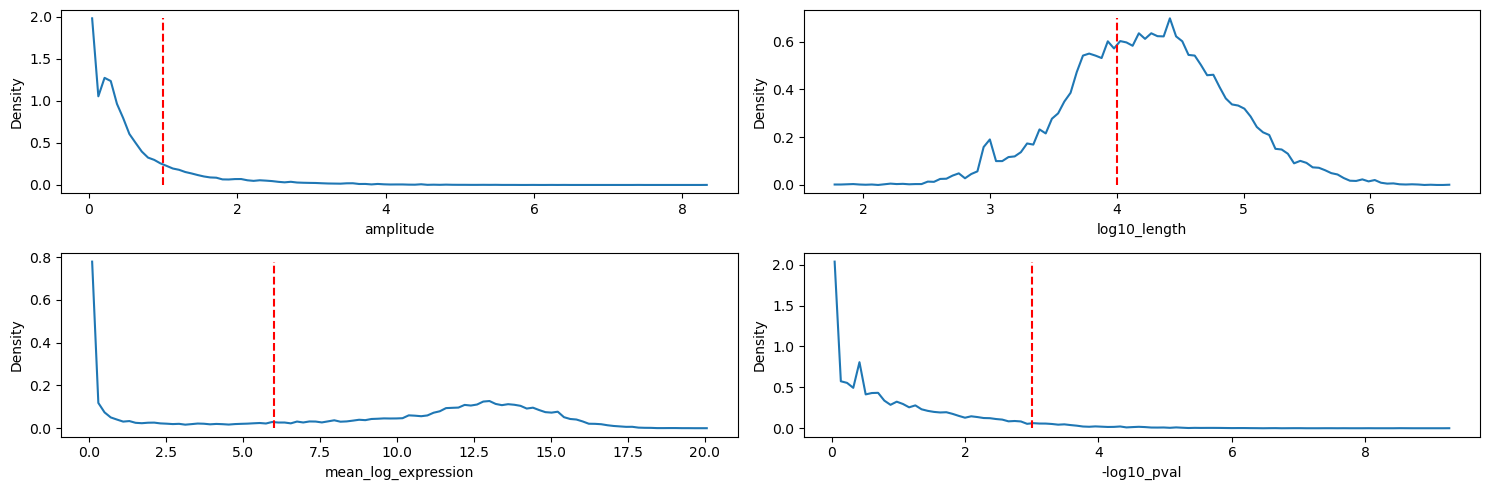

In [33]:

# filter genes w.r.t: amplitude, length, expression
thresholds = {'amplitude':1, 'log10_length':4, 'mean_log_expression':6,'-log10_pval':3}
idx = np.zeros([len(gene_phase_amp),len(thresholds)], dtype=bool)
for j,th in enumerate(thresholds.keys()):
    idx[:,j] = (gene_phase_amp[th] > thresholds[th])
#idx = (gene_phase_amp.amplitude > thresholds['amplitude']) & (gene_phase_amp.log10_length > thresholds['log10_length']) & (gene_phase_amp.mean_log_expression > thresholds['mean_log_expression'])

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 5))
for f, th in enumerate(thresholds.keys()):
    ax = axes.flatten()[f]
    [h,x] = np.histogram(gene_phase_amp[th], bins=100, density=True)
    x = 0.5 * (x[1:] + x[:-1])  # bin centers
    ax.plot(x, h, label=f'{th} histogram')
    ax.vlines(x=thresholds[th], ymin=0, ymax=max(h), color='red', linestyle='--', label=f'{th} threshold')
    ax.set_xlabel(th)
    ax.set_ylabel('Density')

fig.tight_layout()
# filter gene_phase_amp
gene_phase_amp = gene_phase_amp[idx.all(1)].reset_index(drop=True)

# compute average LL and k for each gene in ext. kalman filter results
def get_average_LL_kf_in_coord(coord):
    idx = (kf.chr == coord[0]) & (kf.start >= coord[1]) & (kf.end <= coord[2]) & (kf.strand == coord[3])
    return kf[idx].LL.mean()

def get_average_k_kf_in_coords(coords):
    idx = (kf.chr == coords[0]) & (kf.start >= coords[1]) & (kf.end <= coords[2]) & (kf.strand == coords[3])
    return kf[idx].k.mean()


COORD = gene_phase_amp[['chr','start','end','strand']].values
COORD[:,1] = (np.floor(COORD[:,1]/bin_size)*bin_size).astype(int)
COORD[:,2] = (np.ceil(COORD[:,2]/bin_size)*bin_size).astype(int)

threads = 84
with Pool(processes=threads) as pool:
    OUT_LL = pool.map(get_average_LL_kf_in_coord ,COORD)

with Pool(processes=threads) as pool:
    OUT_k = pool.map(get_average_k_kf_in_coords, COORD)

gene_phase_amp.loc[:,'LL'] = OUT_LL
gene_phase_amp.loc[:,'k'] = OUT_k



In [34]:
idx.all(1).sum()

353

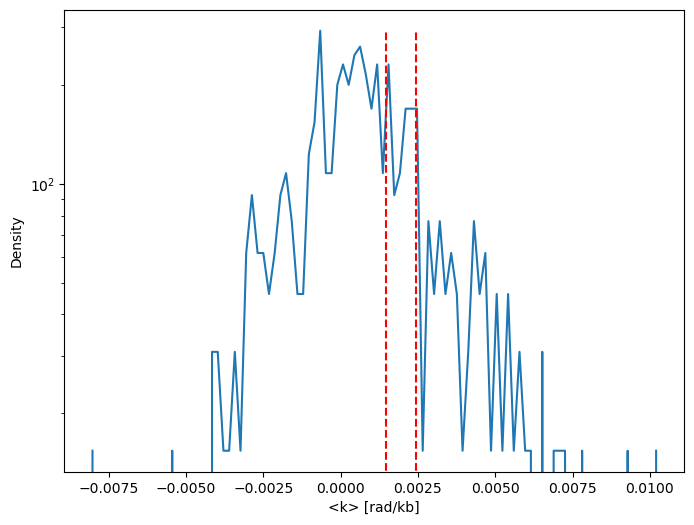

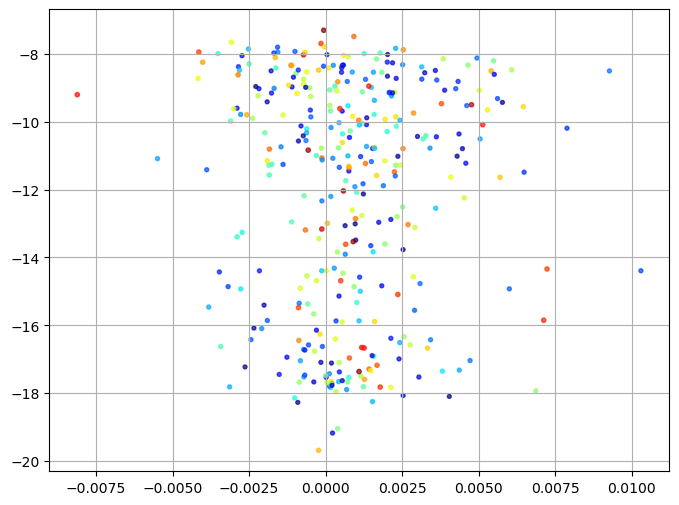

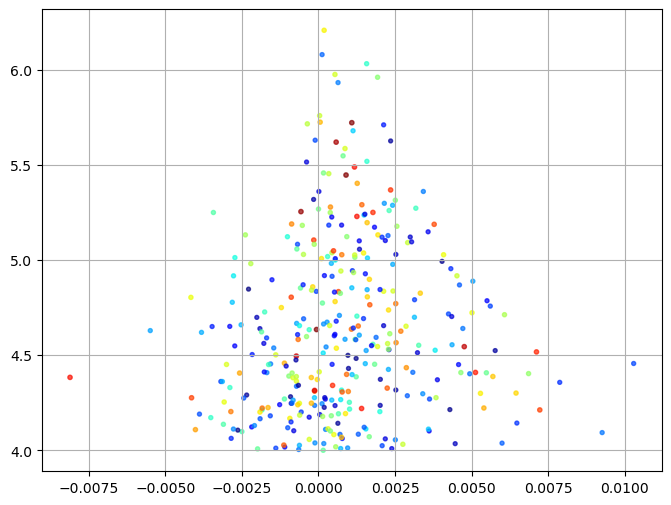

In [35]:
v_range = np.array([30,50]) # [bp/s]
P = 24 # period
ω = 2*np.pi/P # angular frequency [rad/h]
k_range = (ω/3600)/(v_range*1e-3) # [rad/kb]

fig, ax = plt.subplots(figsize=(8, 6))

h, x = np.histogram(gene_phase_amp.k, bins=100, density=True)
x = 0.5 * (x[1:] + x[:-1])  # bin centers
ax.plot(x, h, label='k histogram')
ax.vlines(x=k_range[0], ymin=0, ymax=max(h), color='red', linestyle='--', label='k threshold')
ax.vlines(x=k_range[1], ymin=0, ymax=max(h), color='red', linestyle='--', label='k threshold')
ax.set_yscale('log')
ax.set_xlabel('<k> [rad/kb]')
ax.set_ylabel('Density')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gene_phase_amp.k, gene_phase_amp.LL, s=10*gene_phase_amp.R2, c = gene_phase_amp['R2'], cmap='jet', alpha=0.7)
ax.grid()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gene_phase_amp.k, gene_phase_amp.log10_length, s=10*gene_phase_amp.R2, c = gene_phase_amp['R2'], cmap='jet', alpha=0.7)
ax.grid()
